In [1]:
QUERIES: list[dict] = [
    {
        "id": 0,
        "query": "Quels sont les articles parus entre le 3 mars 2013 et le 4 mai 2013 évoquant les Etats-Unis ?",
        "relevant_ids": {72932},
    },
    {
        "id": 1,
        "query": "J’aimerais la liste des articles écrits après janvier 2014 et qui parlent d’informatique ou de télécommunications.",
        "relevant_ids": {75063, 75067, 75459, 75462, 75788, 75789, 75791, 75796, 76207, 76507, 76508, 76509},
    },
    {
        "id": 2,
        "query": "Je veux les articles qui parlent des systèmes embarqués et non pas la robotique.",
        "relevant_ids": {67796, 74751},
    },
    {
        "id": 3,
        "query": "Je veux voir les articles de la rubrique Focus et publiés entre 30/08/2011 et 29/09/2011.\"",
        "relevant_ids": {67553, 67554, 67555, 67794, 67795},
    },
    {
        "id": 4,
        "query": "Quels sont les articles traitant d’informatique ou de réseaux.",
        "relevant_ids": {67945, 69540, 70423, 70914, 71359, 71841, 73879, 74452, 74453, 74744, 74751, 75063, 75796, 76207, 76510},
    },
    {
        "id": 5,
        "query": "Chercher les articles dans le domaine industriel et datés à partir de 2012.",
        "relevant_ids": {68881, 68882, 68885, 69179, 69534, 69535, 69541, 69543, 69815, 69818, 69819, 69820, 70161, 70167, 70168, 70169, 70426, 70748, 70752, 70753, 70920, 71358, 71359, 71360, 71361, 71362, 71614, 71615, 71619, 71839, 71840, 71845, 72113, 72114, 72118, 72121, 72122, 72392, 72394, 72396, 72400, 72629, 72634, 72933, 72936, 72937, 72938, 73182, 73190, 73432, 73685, 73690, 73691, 73875, 73879, 73882, 73883, 73884, 74167, 74172, 74174, 74450, 74456, 74744, 74745, 74746, 74747, 74748, 75068, 75069, 75071, 75457, 75462, 75464, 75465, 75466, 75791, 75792, 75794, 75795, 75796, 76210, 76211, 76514},
    },
    {
        "id": 6,
        "query": "Je veux les articles de 2014 et de la rubrique Focus et parlant de la santé.",
        "relevant_ids": {75065, 75459, 76507, 76508},
    },
    {
        "id": 7,
        "query": "Quels sont les articles dont le titre contient le terme 'marché' et le mot 'projet' ?",
        "relevant_ids": {72634},
    },
    {
        "id": 8,
        "query": "Je veux les articles qui parlent du fauteuil roulant et qui ont pour rubrique Actualité Innovation.",
        "relevant_ids": {67940},
    },
    {
        "id": 9,
        "query": "Listez-moi les articles qui parlent de 3D et qui sont écrits entre 2010 et 2011.",
        "relevant_ids": {67554, 68391},
    },
]

In [14]:
from lo17_dm.SearchEngine import SearchEngine
from lo17_dm.Pretraiteur import Pretraiteur
import numpy as np
import seaborn as sns
import pandas as pd

engine = SearchEngine(output_dir="../outputs", corpus_path="../outputs/clean_corpus.xml")
pretraiteur = Pretraiteur(lemma_table_path="../outputs/lemmes_corpus.tsv", rubriques_index_path="../outputs/index/index_rubrique.tsv", stop_words_path="../outputs/stop_words.txt")



In [9]:
TPs = []
FPs = []
FNs = []
for query in QUERIES : 
    requete_dict = pretraiteur.treat_request(query["query"])
    res = engine.search(requete_dict)
    ids = {res["id"] for res in res}
    rel_ids = set(query["relevant_ids"])
    TPs.append(len(ids & rel_ids))
    FPs.append(len(ids - rel_ids))
    FNs.append(len(rel_ids - ids))

TPs = np.array(TPs)
FPs = np.array(FPs)
FNs = np.array(FNs)

In [ ]:
res_df = pd.DataFrame()
res_df["Prec"] = TPs / (TPs + FPs)
res_df["Rec"] = TPs / (TPs + FNs)
res_df["F1"] = 2 * res_df["Prec"] * res_df["Rec"] / (res_df["Prec"] + res_df["Rec"])
res_df.index = range(1, len(res_df) + 1)
res_df

/var/folders/7q/d9s24s2135j03ltrsf6678640000gn/T/ipykernel_17430/3201075722.py:2: RuntimeWarning: invalid value encountered in divide
  res_df["Prec"] = TPs / (TPs + FPs)


,Prec,Rec,F1
0,1.000000,1.000000,1.000000
1,0.800000,0.333333,0.470588
2,0.142857,0.500000,0.222222
3,1.000000,0.200000,0.333333
4,0.155172,0.600000,0.246575
5,NaN,0.000000,NaN
6,0.666667,0.500000,0.571429
7,NaN,0.000000,NaN
8,1.000000,1.000000,1.000000
9,1.000000,1.000000,1.000000


/var/folders/7q/d9s24s2135j03ltrsf6678640000gn/T/ipykernel_17430/2709024891.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=res_df.index, y=res_df["Prec"], ax=axes[0], palette="Blues_d")
/var/folders/7q/d9s24s2135j03ltrsf6678640000gn/T/ipykernel_17430/2709024891.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=res_df.index, y=res_df["Rec"], ax=axes[1], palette="Greens_d")
/var/folders/7q/d9s24s2135j03ltrsf6678640000gn/T/ipykernel_17430/2709024891.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=res_df.index, y=res_df["F1"],

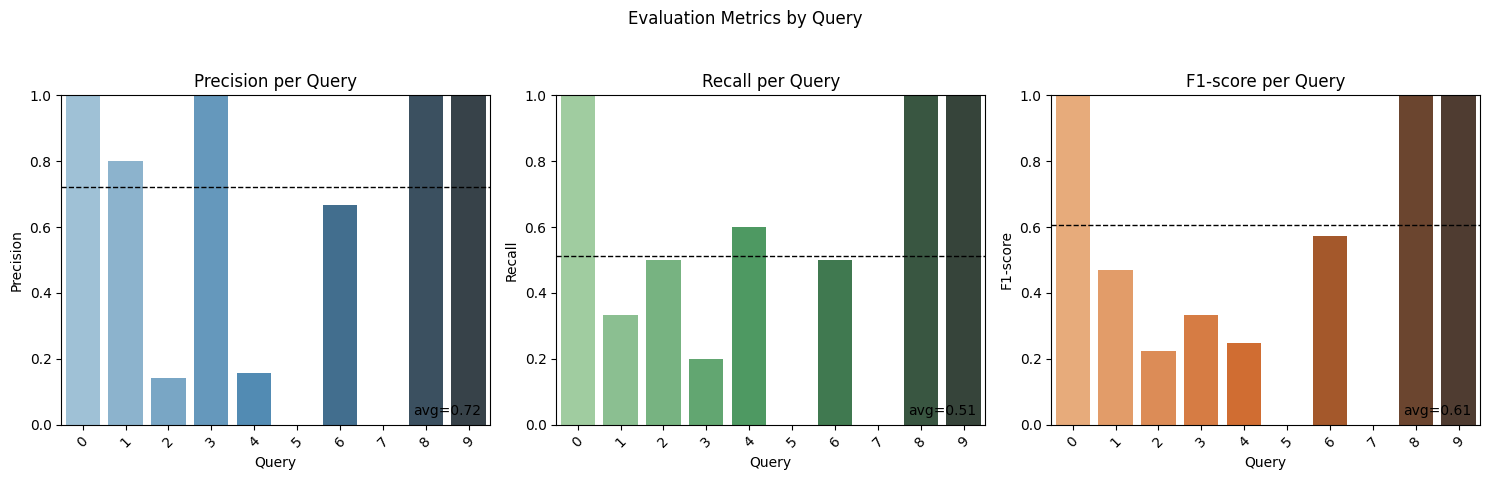

In [19]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
# Precision
sns.barplot(x=res_df.index, y=res_df["Prec"], ax=axes[0], palette="Blues_d")
axes[0].set_title("Precision per Query")
axes[0].set_xlabel("Query")
axes[0].set_ylabel("Precision")
axes[0].set_ylim(0, 1)
axes[0].axhline(res_df["Prec"].mean(), color="k", linestyle="--", linewidth=1)
axes[0].text(0.98, 0.02, f'avg={res_df["Prec"].mean():.2f}', va="bottom", ha="right", transform=axes[0].transAxes)
# Recall
sns.barplot(x=res_df.index, y=res_df["Rec"], ax=axes[1], palette="Greens_d")
axes[1].set_title("Recall per Query")
axes[1].set_xlabel("Query")
axes[1].set_ylabel("Recall")
axes[1].set_ylim(0, 1)
axes[1].axhline(res_df["Rec"].mean(), color="k", linestyle="--", linewidth=1)
axes[1].text(0.98, 0.02, f'avg={res_df["Rec"].mean():.2f}', va="bottom", ha="right", transform=axes[1].transAxes)
# F1
sns.barplot(x=res_df.index, y=res_df["F1"], ax=axes[2], palette="Oranges_d")
axes[2].set_title("F1-score per Query")
axes[2].set_xlabel("Query")
axes[2].set_ylabel("F1-score")
axes[2].set_ylim(0, 1)
axes[2].axhline(res_df["F1"].mean(), color="k", linestyle="--", linewidth=1)
axes[2].text(0.98, 0.02, f'avg={res_df["F1"].mean():.2f}', va="bottom", ha="right", transform=axes[2].transAxes)
for ax in axes:
    ax.set_xticklabels([str(i) for i in res_df.index], rotation=45)
plt.suptitle("Evaluation Metrics by Query")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [20]:
from timeit import default_timer as timer

num_runs = 100
averages = []

for query in QUERIES : 
    average = 0 
    for i in range(num_runs) :
     
        start = timer()
        requete_dict = pretraiteur.treat_request(query["query"])
        res = engine.search(requete_dict)
        end = timer()
        average += end - start

    averages.append(average / num_runs)
    

/var/folders/7q/d9s24s2135j03ltrsf6678640000gn/T/ipykernel_17430/4112080152.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=queries, y=averages, ax=ax, palette="Purples_d")
/var/folders/7q/d9s24s2135j03ltrsf6678640000gn/T/ipykernel_17430/4112080152.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([str(i) for i in queries], rotation=45)


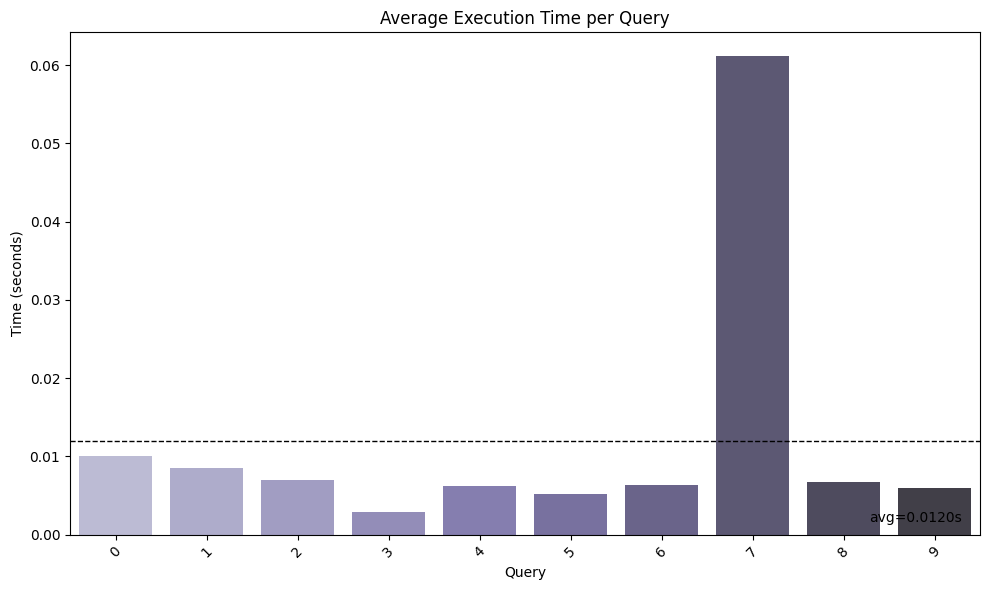

In [24]:
fig, ax = plt.subplots(figsize=(10, 6))
queries = list(range(0, len(averages)))
sns.barplot(x=queries, y=averages, ax=ax, palette="Purples_d")
ax.set_title("Average Execution Time per Query")
ax.set_xlabel("Query")
ax.set_ylabel("Time (seconds)")
ax.set_xticklabels([str(i) for i in queries], rotation=45)
ax.axhline(np.mean(averages), color="k", linestyle="--", linewidth=1)
ax.text(0.98, 0.02, f'avg={np.mean(averages):.4f}s', va="bottom", ha="right", transform=ax.transAxes)
plt.tight_layout()
plt.show()